In [1]:
# Import Modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Set display options to show all columns
pd.set_option('display.max_columns', None)

In [3]:
#Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Prompt 1: Read in the dataset and determine how many rows and columns it has
df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Module 1/Assignment M1/Telco_customer_churn.csv')

# To obtain the number of rows and columns that it has, use df.shape.
df.shape

# Answer: Rows = 7043, columns = 33

(7043, 33)

In [5]:
# Prompt 2: When you open a dataset Python will assume the data types for each column. What are the current continuous variables?
# Utilize select_dtypes to filter columns by data type, in this case int64 and float64
print(df.select_dtypes(include=['int64', 'float64']).head())

# Answer: Count, Zip Code, Latitude, Longitude, Tenure Months, Monthly Charges, Churn Value, Churn Score, CLTV

   Count  Zip Code   Latitude   Longitude  Tenure Months  Monthly Charges  \
0      1     90003  33.964131 -118.272783              2            53.85   
1      1     90005  34.059281 -118.307420              2            70.70   
2      1     90006  34.048013 -118.293953              8            99.65   
3      1     90010  34.062125 -118.315709             28           104.80   
4      1     90015  34.039224 -118.266293             49           103.70   

   Churn Value  Churn Score  CLTV  
0            1           86  3239  
1            1           67  2701  
2            1           86  5372  
3            1           84  5003  
4            1           89  5340  


In [6]:
# Prompt 3: What are the current categorical variables?
# Utilize select_dtypes to filter columns by data type, in this case
df.describe(include='object', exclude=['int64', 'float64']).head()

# Answer: View result returned by the code's execution below.

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174,192


In [7]:
# Prompt 4: Are there any columns that look like they might be the wrong data type?
df.dtypes

# Answer: From my understanding, no, there do not seem to be any columns that look like they might be the wrong data type

,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


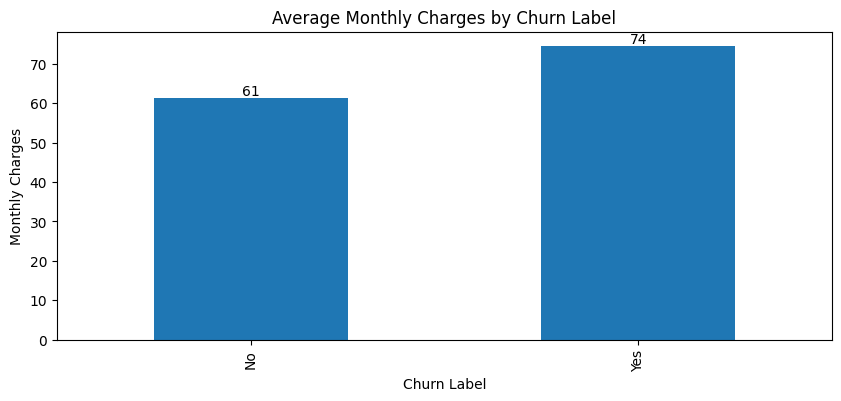

In [8]:
# Prompt 5: Build a bar chart to show average Monthly Charges by Churn Label. How do the monthly changes compare for those who churn and those who do not?
# The following bar chart displays the average monthly charges by churn label
plt.figure(figsize=(10,4))
ax = df.groupby('Churn Label')['Monthly Charges'].mean().plot(kind='bar')
plt.title('Average Monthly Charges by Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')

# Add labels to the bars
ax.bar_label(ax.containers[0], fmt='{:,.0f}')

# Dispay the bar chart
plt.show()

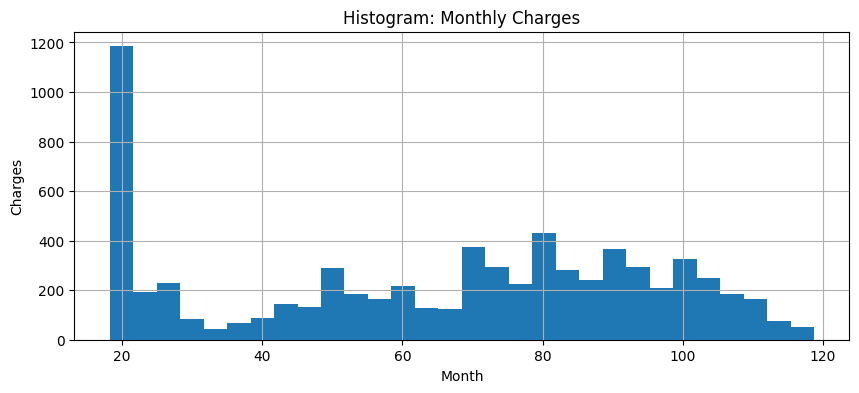

Mean of monthly charges  64.76169246059918


In [9]:
# Prompt 6: Build a histogram of Monthly Charges. Describe some features of the distribution.
import statistics

plt.figure(figsize=(10,4))
df['Monthly Charges'].hist(bins=30)
plt.title('Histogram: Monthly Charges')
plt.xlabel('Month')
plt.ylabel('Charges')
plt.show()

print("Mean of monthly charges " , statistics.mean(df['Monthly Charges']))

# Answer: Some features of this distribution include an approximately 18-fold initial rise
#         in monthly charges between 15 and 21 months, followed by an average monthly price of $65 (estimated)

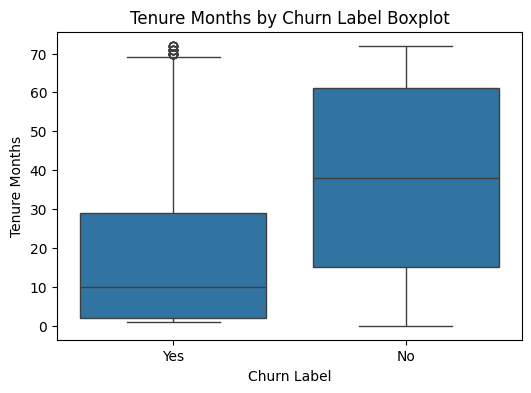

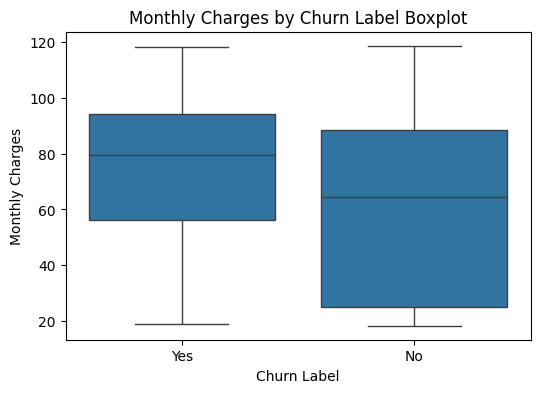

In [10]:
# Prompt 7: Make comparative boxplots for Tenure Months by Churn Label and Monthly Charges by Churn Label. Comment on what you see about Tenure Months and Monthly Charges as possible predictors of churn.
# Box Plot 1: Tenure Months by Churn Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn Label', y='Tenure Months')
plt.title('Tenure Months by Churn Label Boxplot')
plt.show()

# Box Plot 2: Monthly Charges by Churn Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title('Monthly Charges by Churn Label Boxplot')
plt.show()

# Answer: Based on the data presented, I see that individuals who had higher charges on average than those who did not stayed with the company for less time.
# The data suggests that customers were hesitant to stay at the company long-term when charges per month were exceeding approximately $60-$70.

In [11]:
# Prompt 8: Check the correlations of the continuous variables.
# The continuous variables are selected as the first step
continuous_vars = df.select_dtypes(include=['int64', 'float64']).columns

# The correlation table is created
correlation_table = df[continuous_vars].corr()

# The correlation table is displayed with color
print("Correlation Table of Continuous Variables:")
display(correlation_table.style.background_gradient(cmap='coolwarm', axis=None))

Correlation Table of Continuous Variables:


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Count,nan,nan,nan,nan,nan,nan,nan,nan,nan
Zip Code,nan,1.000000,0.895743,-0.784271,0.001041,-0.004596,0.003346,-0.002769,-0.003562
Latitude,nan,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.003384,-0.007684,0.000886
Longitude,nan,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.004594,0.004260,0.000485
Tenure Months,nan,0.001041,-0.001631,-0.001678,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,nan,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,nan,0.003346,-0.003384,0.004594,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,nan,-0.002769,-0.007684,0.004260,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,nan,-0.003562,0.000886,0.000485,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [12]:
# Prompt 9: Check for missing values. What did you find?
# Performs and displays the check for all the missing values in each individual column
print("Missing values per column:")
print(df.isnull().sum())

# Performs and displays the check of the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

# Answer: The column "Churn Reason" was the only column with missing data from it.
#         it included 5174 missing values in the dataset.

Missing values per column:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Total missing values in the dataset:
5174


In [13]:
# Prompt 10: Check for outliers in each of the continuous variables. Do any of them have outliers?
# Select all of the continuous variables
continuous_vars = df.select_dtypes(include=['int64', 'float64']).columns

# Create an array of the continuous variables
continuous_array = np.array(continuous_vars)

# Create a for loop to process outlier logic for all continuous variables
for colName in continuous_array:

  # Display print message of targeted continuous variable
  print(f"Checking for outliers in column: {colName}")

  # Calculate the interquartile range (IQR)
  q1 = df[colName].quantile(0.1)
  q3 = df[colName].quantile(0.9)
  iqr = q3 - q1

  # Define the boundaries for an outlier
  lower_bound = q1 - (3 * iqr)
  upper_bound = q3 + (3 * iqr)

  # Find the outliers through below formula
  outliers = df[(df[colName] < lower_bound) | (df[colName] > upper_bound)]

  # Display the outliers for the current column if they exist
  if not outliers.empty:
      # Display only the outlier values from the current column
      print(f"Outliers found in {colName}: {len(outliers)} outliers")
      print(outliers[colName])
  else:
      # Display a message signifying that no outlier exists for the given column
      print(f"No outliers found in {colName} using the quantile range method.")
  print("-" * 30) # Separator for clarity between columns

# Answer: No, none of the continuous variables have outliers

Checking for outliers in column: Count
No outliers found in Count using the quantile range method.
------------------------------
Checking for outliers in column: Zip Code
No outliers found in Zip Code using the quantile range method.
------------------------------
Checking for outliers in column: Latitude
No outliers found in Latitude using the quantile range method.
------------------------------
Checking for outliers in column: Longitude
No outliers found in Longitude using the quantile range method.
------------------------------
Checking for outliers in column: Tenure Months
No outliers found in Tenure Months using the quantile range method.
------------------------------
Checking for outliers in column: Monthly Charges
No outliers found in Monthly Charges using the quantile range method.
------------------------------
Checking for outliers in column: Churn Value
No outliers found in Churn Value using the quantile range method.
------------------------------
Checking for outliers 

            Country       State          City                Lat Long  \
423   United States  California       Alturas   41.468877, -120.54229   
424   United States  California   Davis Creek  41.750354, -120.403885   
425   United States  California  Fort Bidwell  41.932207, -120.135941   
426   United States  California     Lake City  41.729079, -120.225025   
853   United States  California    Eagleville  41.280341, -120.150381   
854   United States  California  Fort Bidwell  41.932207, -120.135941   
855   United States  California     Lake City  41.729079, -120.225025   
1287  United States  California    Eagleville  41.280341, -120.150381   
1288  United States  California     Lake City  41.729079, -120.225025   
1407  United States  California    Parker Dam  34.273872, -114.192901   
2166  United States  California          Earp   34.137742, -114.36514   
2178  United States  California    Parker Dam  34.273872, -114.192901   
3012  United States  California         Canby  41.4

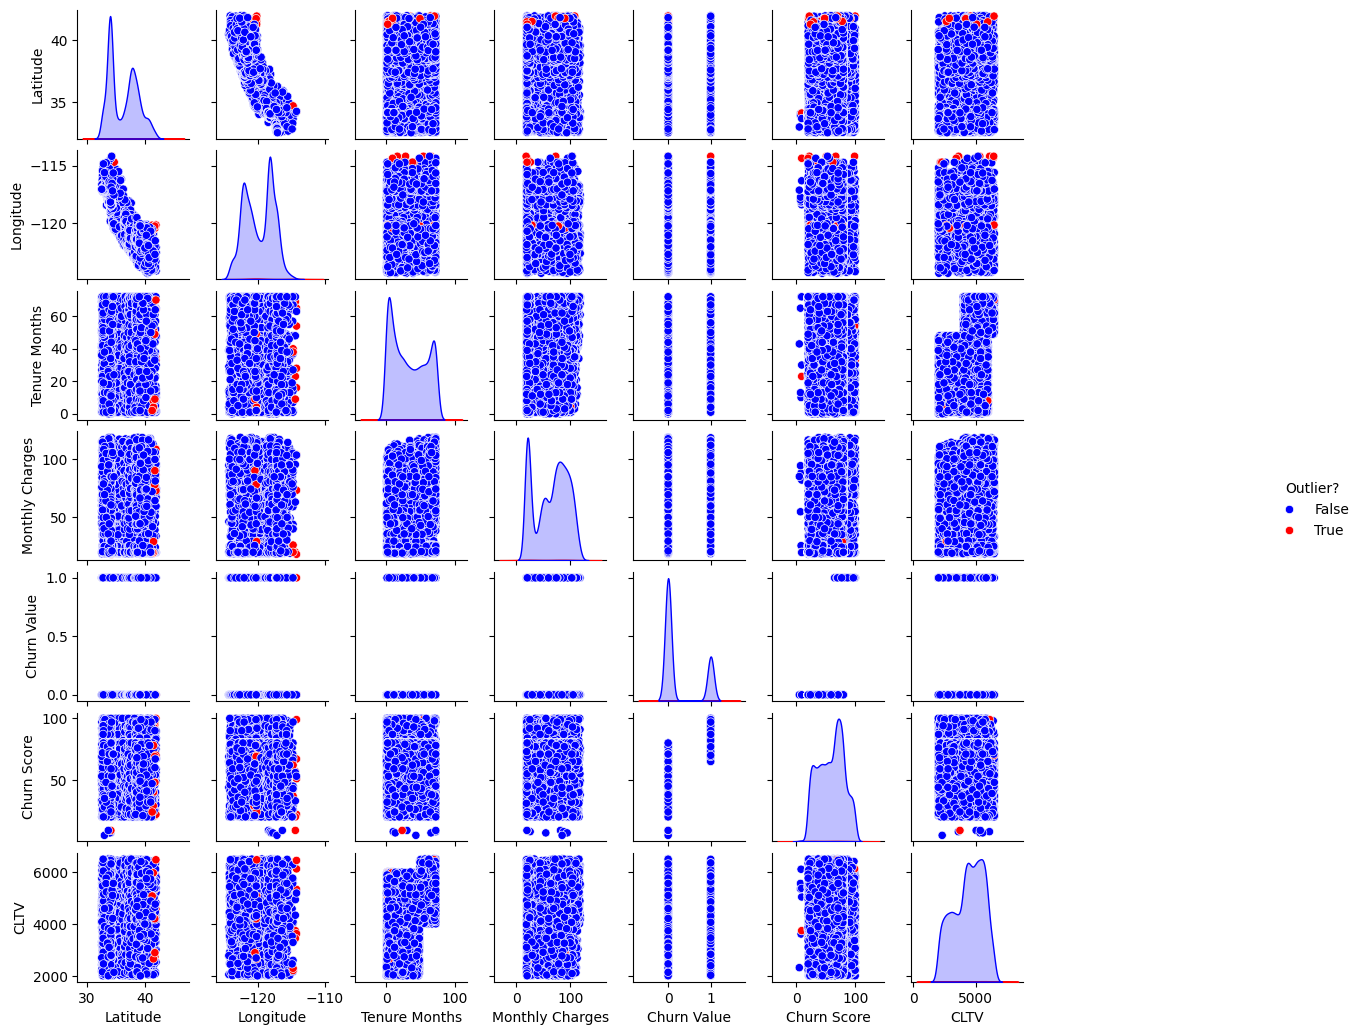

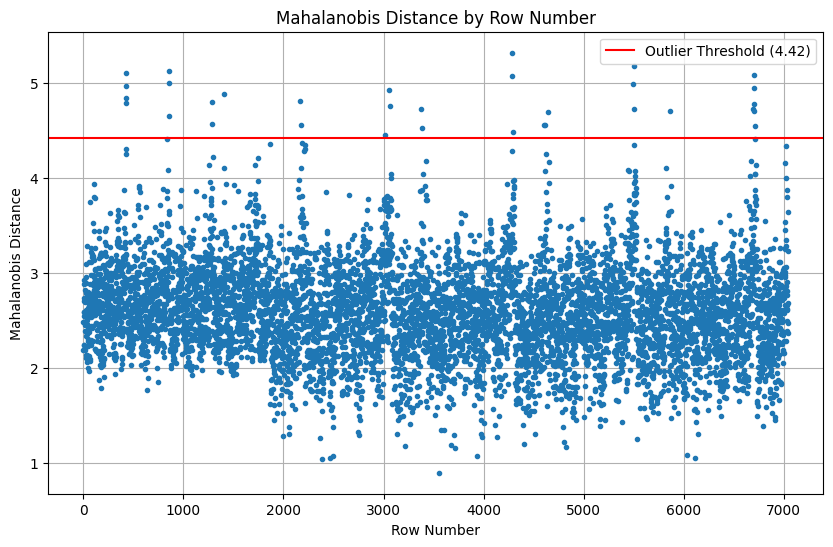

In [14]:
# Prompt 11: Check for row outliers using Mahalanobis distance. What did you find?
import pandas as pd
from scipy.spatial.distance import mahalanobis

# Remove the 'CustomerID' and 'Count' and 'Zip Code' columns as they are either identifiers, have zero variance, or are highly correlated with other columns
cols_to_drop = ['CustomerID', 'Count', 'Zip Code']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Subset the DataFrame to only include columns with numeric data, creating a copy to avoid modifying the original DataFrame
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols].copy()

# Handle missing values using mean imputation
for col in df_numeric.columns:
    if df_numeric[col].isnull().any():
        mean_val = df_numeric[col].mean()
        df_numeric[col] = df_numeric[col].fillna(mean_val)

# Calculate Mahalanobis distance for each row
cov = df_numeric.cov()
# Check if the covariance matrix is singular before inverting
try:
    inv_cov = pd.DataFrame(np.linalg.inv(cov.values), index=cov.index, columns=cov.columns)
    mean = df_numeric.mean()
    distances = []
    for i, row in df_numeric.iterrows():
        distances.append(mahalanobis(row, mean, inv_cov))

    # Calculate threshold for outliers (default value used)
    threshold = np.mean(distances) * 1.7

    # Create new column in DataFrame to flag outliers
    df['is_outlier'] = pd.Series([dist > threshold for dist in distances], index=df_numeric.index)

    # Print rows that are flagged as outliers
    print(df[df['is_outlier']])

    # Create a scatterplot matrix of the numeric columns and color the points based on is_outlier
    g = sns.pairplot(df, height=1.5, hue='is_outlier', palette=['blue', 'red'])

    # Remove the legend title and adjust the legend position
    g._legend.set_title('Outlier?')
    g._legend.set_bbox_to_anchor([1.2, 0.5])

    # Show the plot
    plt.show()

except np.linalg.LinAlgError:
    print("Error: The covariance matrix is singular. Could not calculate Mahalanobis distance.")

# Plot Mahalanobis distances
plt.figure(figsize=(10, 6))

# Use df.index as the x-axis since distances correspond to the original DataFrame rows
plt.plot(df_numeric.index, distances, marker='o', linestyle='', markersize=3)
plt.axhline(y=threshold, color='r', linestyle='-', label=f'Outlier Threshold ({threshold:.2f})')
plt.title('Mahalanobis Distance by Row Number')
plt.xlabel('Row Number')
plt.ylabel('Mahalanobis Distance')
plt.legend()
plt.grid(True)
plt.show()

# Answer: I found that 32 rows were identified as outliers.